# In the previous two notebooks, we implemented the bivariate parametrisation given in JASA2012.  In this notebook, we implement its 3-variate version.  Most of the code should be identical to notebook 22, but the parametrisation becomes more complicated.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import random
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize
from scipy.special import beta as B
from scipy.special import gamma as Gamma

In [2]:
number_of_simulations = 100  # Number of iterations
data_size = 750 # Size of Points per iteration

In [3]:
# number_of_simulations = 10  # Number of iterations
# data_size = 10 # Size of Points per iteration

In [4]:
# Define the Matern covariance function
# Define the Matern covariance function
def matern_covariance(X, length_scale=1.0, nu=1.5, sigma2=1.0):
    # Define the Matern kernel with specific parameters
    matern_kernel = Matern(length_scale=length_scale, nu=nu)
    
    # Combine with a ConstantKernel to include sigma2
    kernel = ConstantKernel(constant_value=sigma2) * matern_kernel
    
    # Compute the covariance matrix
    cov_matrix = kernel(X)
    return cov_matrix

# Generate marginal Matern covariance matrix 
def generate_marginal_matern_covariance(X, params_marginal, nugget = 1e-6):
    a, nu, sigma = params_marginal
    K = matern_covariance(X, length_scale = a, nu=nu, sigma2=sigma**2)
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    K = (K+K.T)/2
    return K

# Generate trivariate Matern covariance matrix with distinct parameters
def generate_trivariate_matern_covariance(X, params, nugget=1e-6):
    nu1, a1, sigma_1, nu2, a2, sigma_2, nu3, a3, sigma_3, nu12, a12, sigma_12, nu13, a13, sigma_13, nu23, a23, sigma_23 = params
    # Compute the Matern covariance matrices for each variable and cross-covariances
    K1 = matern_covariance(X, length_scale=a1, nu=nu1, sigma2=sigma_1**2)
    K2 = matern_covariance(X, length_scale=a2, nu=nu2, sigma2=sigma_2**2)
    K3 = matern_covariance(X, length_scale=a3, nu=nu3, sigma2=sigma_3**2)
    K12 = matern_covariance(X, length_scale=a12, nu=nu12, sigma2=sigma_12**2)
    K13 = matern_covariance(X, length_scale=a13, nu=nu13, sigma2=sigma_13**2)
    K23 = matern_covariance(X, length_scale=a23, nu=nu23, sigma2=sigma_23**2)
    
    # Construct the full trivariate covariance matrix
    K = np.block([
        [K1, K12, K13],
        [K12.T, K2, K23],
        [K13.T, K23.T, K3]
    ])
    
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    K = (K+K.T)/2
    return K

# Check if matrix is positive definite
def is_positive_definite(K):
    try:
        np.linalg.cholesky(K)
        return True
    except np.linalg.LinAlgError:
        return False

# Negative log-likelihood function for optimization
def negative_log_likelihood_marginal(params_marginal, X, y):
    K = generate_marginal_matern_covariance(X, params_marginal)
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf

# Plotting function for data 
def plot_trivariate_data_and_fields(X, data):
    # Plotting the data
    plt.figure(figsize=(18, 6))
    
    # Plot for Variable 1
    plt.subplot(1, 3, 1)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 0], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 1 Values')
    plt.title('Spatial Distribution for Variable 1')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)
    
    # Plot for Variable 2
    plt.subplot(1, 3, 2)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 1], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 2 Values')
    plt.title('Spatial Distribution for Variable 2')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)
    
    # Plot for Variable 3
    plt.subplot(1, 3, 3)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 2], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 3 Values')
    plt.title('Spatial Distribution for Variable 3')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def optimise_marginal (y_data):
    # Bounds and options for the optimizer
    bounds = [
        (np.finfo(np.float32).eps, 10.0),  # nu: smoothness parameter for the variable
        (np.finfo(np.float32).eps, 10.0),  # a: length scale for the variable
        (-5.0, 5.0),      # sigma: standard deviation for the variable
    ]
    options = {'maxiter': 1000, 'gtol': 1e-14}
    initial_params_marginal = [1.0, 0.1, 1.0]
    
    # Minimize the negative log-likelihood
    result = minimize(negative_log_likelihood_marginal, initial_params_marginal, args=(X, y_data), bounds=bounds, options=options)
    return result


# Simulate the Data
def simulate_trivariate_data(initial_params = [1.2, 0.01, 1.0, 0.6, 0.02, 1.0, 0.3, 0.03, 1.0, 1.093, 0.0205, -0.286, 1.092, 0.0263, -0.181, 0.990, 0.0282, 0.274], data_size = 500):
    p = 3
    X = np.random.uniform(-3., 3., (data_size, p))
    # Generate covariance matrix
    mean = np.zeros(p * len(X))
    K = generate_trivariate_matern_covariance(X, initial_params)    
    data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 3)
    
    # # Check if matrix is positive definite
    # print("Is the covariance matrix positive definite?", is_positive_definite(K))

    
    # Generate and Flatten the data for optimization
    y_data = data.reshape(-1)
    y_data_first = y_data[:data_size]
    y_data_second = y_data[data_size:2*data_size]
    y_data_third = y_data[2*data_size:]
    return (X, y_data, y_data_first, y_data_second, y_data_third, data)

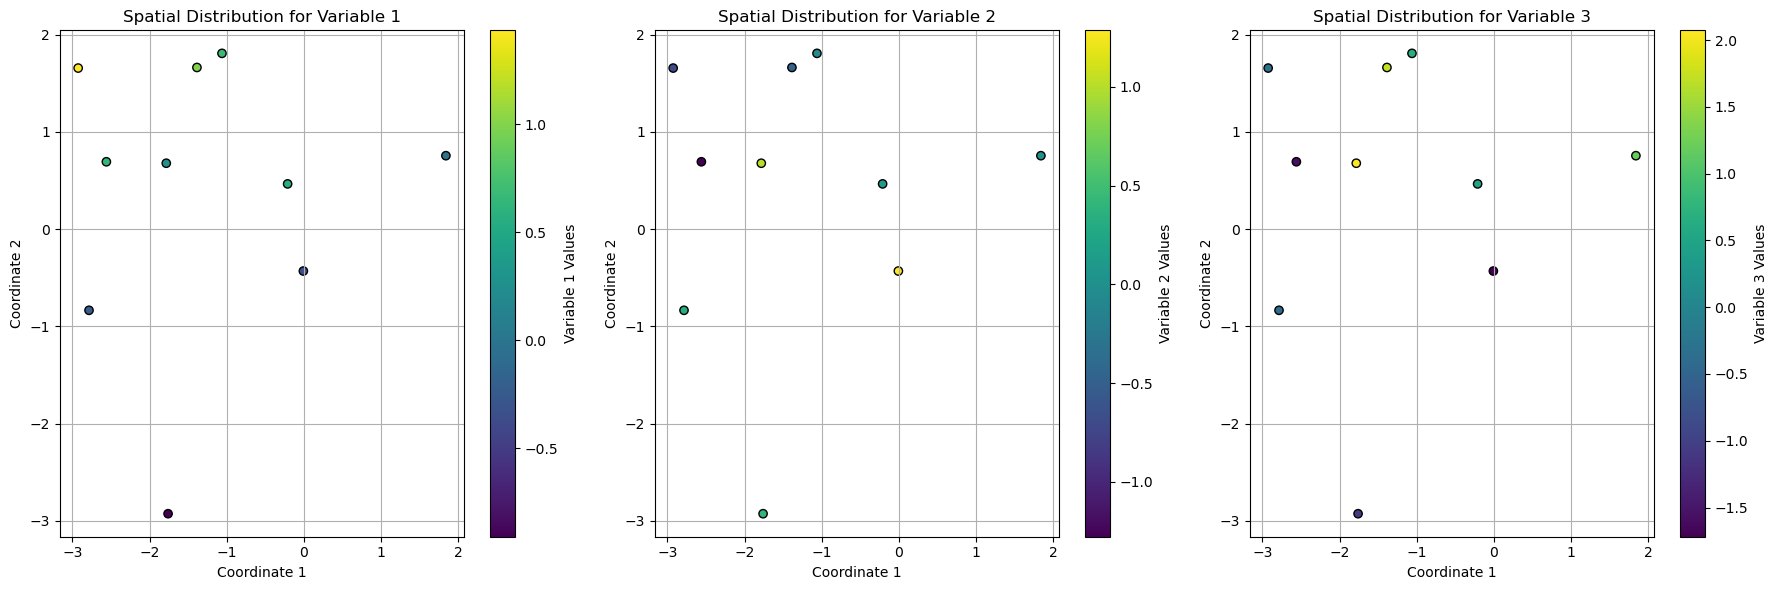

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 13.10742265409229
        x: [ 9.462e-01  1.192e-07  8.975e-01]
      nit: 5
      jac: [ 7.105e-07  4.474e+01  1.421e-06]
     nfev: 40
     njev: 10
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64> 


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 12.082336071486418
        x: [ 8.696e-01  1.474e-01  8.145e-01]
      nit: 14
      jac: [-1.421e-06  1.243e-06 -2.309e-05]
     nfev: 72
     njev: 18
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64> 


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 14.663156963745688
        x: [ 3.427e+00  8.407e-02  1.094e+00]
      nit: 18
      jac: [ 0.000e+00  3.553e-07  3.908e-06]
     nfev: 84
     njev: 21
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [5]:
# First, let us look at one instantiation.

# Simulate trivariate data
X, y_data, y_data_first, y_data_second, y_data_third, data = simulate_trivariate_data(data_size = 10)

# Visualise the data
plot_trivariate_data_and_fields(X,data)

# We first estimate the parameters that depend only marginally on one variable

##  Estimate the three variables marginally. 
result_first = optimise_marginal(y_data_first)
result_second = optimise_marginal(y_data_second)
result_third = optimise_marginal(y_data_third)

print(result_first, "\n\n")
print(result_second, "\n\n")
print(result_third)

nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x
nu3_estimated, a3_estimated, sigma_3_estimated = result_third.x
estimated_params = [nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, a2_estimated, sigma_2_estimated, nu3_estimated, a3_estimated, sigma_3_estimated]

In [6]:
# Next, we estimate the remaining parameters as per Genton's JASA 2012 paper

# Genton's formula (6), (7), (8) 
def calculate_sigma_ij(Wii, Wjj, rho_V, aij, Delta_A, nu_ii, nu_jj, nu_ij):
    dim = 2
    # Calculate the first part of the formula
    first_part = Wii * Wjj * rho_V * aij ** (- 2 * Delta_A - (nu_ii + nu_jj))

    # Calculate the second part involving the Gamma functions
    gamma_part = Gamma((nu_ii + nu_jj) / 2 + dim / 2) * Gamma(nu_ij) / (Gamma(nu_ij + dim / 2))

    return first_part * gamma_part
    

def trivariate_Genton_parametrisation(trivariate_Genton_params, estimated_params):
    nu1, a1, sigma_1, nu2, a2, sigma_2, nu3, a3, sigma_3 = estimated_params # 3*3 = 9 in total
    rho_A, rho_B, rho_V, Delta_A, Delta_B, W1, W2, W3 = trivariate_Genton_params # 8 in total

    a12 = np.sqrt(a1**2 /2 + a2**2 /2 + Delta_B * (1-rho_B))
    a13 = np.sqrt(a1**2 /2 + a3**2 /2 + Delta_B * (1-rho_B))
    a23 = np.sqrt(a2**2 /2 + a3**2 /2 + Delta_B * (1-rho_B))
    
    nu12 = nu1/2+nu2/2 + Delta_A * (1-rho_A)
    nu13 = nu1/2+nu3/2 + Delta_A * (1-rho_A)
    nu23 = nu2/2+nu3/2 + Delta_A * (1-rho_A)

    sigma_12 = calculate_sigma_ij(W1, W2, rho_V, a12, Delta_A, nu1, nu2, nu12)
    sigma_13 = calculate_sigma_ij(W1, W3, rho_V, a13, Delta_A, nu1, nu3, nu13)
    sigma_23 = calculate_sigma_ij(W2, W3, rho_V, a23, Delta_A, nu2, nu3, nu23)
    
    return (nu1, a1, sigma_1, nu2, a2, sigma_2, nu3, a3, sigma_3, nu12, a12, sigma_12, nu13, a13, sigma_13, nu23, a23, sigma_23)

# Searching for valid initial Genton parameters.  This is important.  
# Otherwise, we cannot know what x0 to use for the optimisation process

def random_search_positive_definite(X, estimated_params, num_params=8, lower_bound=np.finfo(np.float32).eps, upper_bound=1.0):
    while True:
        # Randomly generate a set of parameters within the specified bounds
        selected_params = [random.uniform(lower_bound, upper_bound) for _ in range(num_params)]
        
        # Generate the covariance matrix K using the randomly generated parameters
        params = trivariate_Genton_parametrisation(selected_params, estimated_params)
        K = generate_trivariate_matern_covariance(X, params)
        
        # Check if K is positive definite
        if is_positive_definite(K):
            # print("Found a positive definite matrix with parameters:", selected_params)
            return selected_params

# Negative log-likelihood function for optimization.  This is the objective function
def negative_log_likelihood_trivariate_Genton(trivariate_Genton_params, X, y, estimated_params):
    K = generate_trivariate_matern_covariance(X, trivariate_Genton_parametrisation(trivariate_Genton_params, estimated_params))
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf

# The main function for optimisation
def optimise_trivariate_Genton (y_data, estimated_params):
    # Bounds and options for the optimizer
    bounds = [
        (-1+np.finfo(np.float32).eps, 1-np.finfo(np.float32).eps), # rho_A, 
        (-1+np.finfo(np.float32).eps, 1-np.finfo(np.float32).eps), # rho_B, 
        (-1+np.finfo(np.float32).eps, 1-np.finfo(np.float32).eps), # rho_V, 
        (np.finfo(np.float32).eps, 10.0), # Delta_A, 
        (np.finfo(np.float32).eps, 10.0),  # Delta_B, 
        (np.finfo(np.float32).eps, 1-np.finfo(np.float32).eps),  # W1, 
        (np.finfo(np.float32).eps, 1-np.finfo(np.float32).eps),  # W2, 
        (np.finfo(np.float32).eps, 1-np.finfo(np.float32).eps),  # W3
    ]
    options = {'maxiter': 1000, 'gtol': 1e-14}
    
    initial_trivariate_Genton_params = random_search_positive_definite(X, estimated_params) # search for initialisation
    
    # Minimize the negative log-likelihood
    result = minimize(negative_log_likelihood_trivariate_Genton, initial_trivariate_Genton_params, args=(X, y_data, estimated_params), bounds=bounds, options=options, method = "trust-constr")
    # result = minimize(negative_log_likelihood_trivariate_Genton, initial_trivariate_Genton_params, args=(X, y_data, estimated_params), bounds=bounds, options=options)

    return result

# estimate the remaining parameters in Genton's parametrisation
result_trivariate_Genton = optimise_trivariate_Genton(y_data, estimated_params)

nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, a2_estimated, sigma_2, nu3_estimated, a3_estimated, sigma_3_estimated, nu12_estimated, a12_estimated, sigma_12_estimated, nu13_estimated, a13_estimated, sigma_13_estimated, nu23_estimated, a23_estimated, sigma_23_estimated = trivariate_Genton_parametrisation(result_trivariate_Genton.x, estimated_params)

# Create a DataFrame for this single estimation
df_one_estimate = pd.DataFrame({
    'nu1': [nu1_estimated], 'a1': [a1_estimated], 'sigma_1': [sigma_1_estimated], 
    'nu2': [nu2_estimated], 'a2': [a2_estimated], 'sigma_2': [sigma_2_estimated], 
    'nu3': [nu3_estimated], 'a3': [a3_estimated], 'sigma_3': [sigma_3_estimated], 
    'nu12': [nu12_estimated], 'a12': [a12_estimated], 'sigma_12': [sigma_12_estimated], 
    'nu13': [nu13_estimated], 'a13': [a13_estimated], 'sigma_13': [sigma_13_estimated], 
    'nu23': [nu23_estimated], 'a23': [a23_estimated], 'sigma_23': [sigma_23_estimated]
})
df_one_estimate

# The above two steps are iterated many times to check for performance over random realisations

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


,nu1,a1,sigma_1,nu2,a2,sigma_2,nu3,a3,sigma_3,nu12,a12,sigma_12,nu13,a13,sigma_13,nu23,a23,sigma_23
0,0.946212,1.192093e-07,0.897451,0.869595,0.147363,0.814498,3.42654,0.084075,1.094145,1.361793,0.228168,-0.296264,2.640265,0.211511,-0.641028,2.601956,0.235786,-0.505765


In [7]:
# Store the ground truth parameters
true_nu1_value, true_a1_value, true_sigma_1_value, true_nu2_value, true_a2_value, \
true_sigma_2_value, true_nu3_value, true_a3_value, true_sigma_3_value, true_nu12_value, \
true_a12_value, true_sigma_12_value, true_nu13_value, true_a13_value, true_sigma_13_value, \
true_nu23_value, true_a23_value, true_sigma_23_value = [
    1.2, 0.01, 1.0, 0.6, 0.02, 1.0, 0.3, 0.03, 1.0, 1.093, 0.0205, -0.286, 
    1.092, 0.0263, -0.181, 0.990, 0.0282, 0.274
]
true_values = {
    'nu1': true_nu1_value,
    'a1': true_a1_value,
    'sigma_1': true_sigma_1_value,
    'nu2': true_nu2_value,
    'a2': true_a2_value,
    'sigma_2': true_sigma_2_value,
    'nu3': true_nu3_value,
    'a3': true_a3_value,
    'sigma_3': true_sigma_3_value,
    'nu12': true_nu12_value,
    'a12': true_a12_value,
    'sigma_12': true_sigma_12_value,
    'nu13': true_nu13_value,
    'a13': true_a13_value,
    'sigma_13': true_sigma_13_value,
    'nu23': true_nu23_value,
    'a23': true_a23_value,
    'sigma_23': true_sigma_23_value
}
columns = [
    'nu1', 'a1', 'sigma_1', 'nu2', 'a2', 'sigma_2', 'nu3', 'a3', 'sigma_3',
    'nu12', 'a12', 'sigma_12', 'nu13', 'a13', 'sigma_13', 'nu23', 'a23', 'sigma_23'
]

# Prepare a list to collect the results
results = []

In [8]:
for _ in range(number_of_simulations):
    try:
        X, y_data, y_data_first, y_data_second, y_data_third, data = simulate_trivariate_data(data_size=data_size)
    
        # Estimate the first 9 parameters marginally
        result_first = optimise_marginal(y_data_first)
        result_second = optimise_marginal(y_data_second)
        result_third = optimise_marginal(y_data_third)
        
        nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
        nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x
        nu3_estimated, a3_estimated, sigma_3_estimated = result_third.x
        
        estimated_params = [
            nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, 
            a2_estimated, sigma_2_estimated, nu3_estimated, a3_estimated, 
            sigma_3_estimated
        ]
    
        # Estimate the remaining parameters in Genton's parametrisation
        result_trivariate_Genton = optimise_trivariate_Genton(y_data, estimated_params)
        
        nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, a2_estimated, sigma_2, \
        nu3_estimated, a3_estimated, sigma_3_estimated, nu12_estimated, a12_estimated, sigma_12_estimated, \
        nu13_estimated, a13_estimated, sigma_13_estimated, nu23_estimated, a23_estimated, sigma_23_estimated = \
        trivariate_Genton_parametrisation(result_trivariate_Genton.x, estimated_params)
        
        # Append the results to the list
        results.append({
            'nu1': nu1_estimated, 'a1': a1_estimated, 'sigma_1': sigma_1_estimated, 
            'nu2': nu2_estimated, 'a2': a2_estimated, 'sigma_2': sigma_2_estimated, 
            'nu3': nu3_estimated, 'a3': a3_estimated, 'sigma_3': sigma_3_estimated, 
            'nu12': nu12_estimated, 'a12': a12_estimated, 'sigma_12': sigma_12_estimated, 
            'nu13': nu13_estimated, 'a13': a13_estimated, 'sigma_13': sigma_13_estimated, 
            'nu23': nu23_estimated, 'a23': a23_estimated, 'sigma_23': sigma_23_estimated
        })
    except Exception as e:
        print(f"An error occurred: {e}")
        continue
    
# Convert the list of results into a DataFrame
df_estimates = pd.DataFrame(results)

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


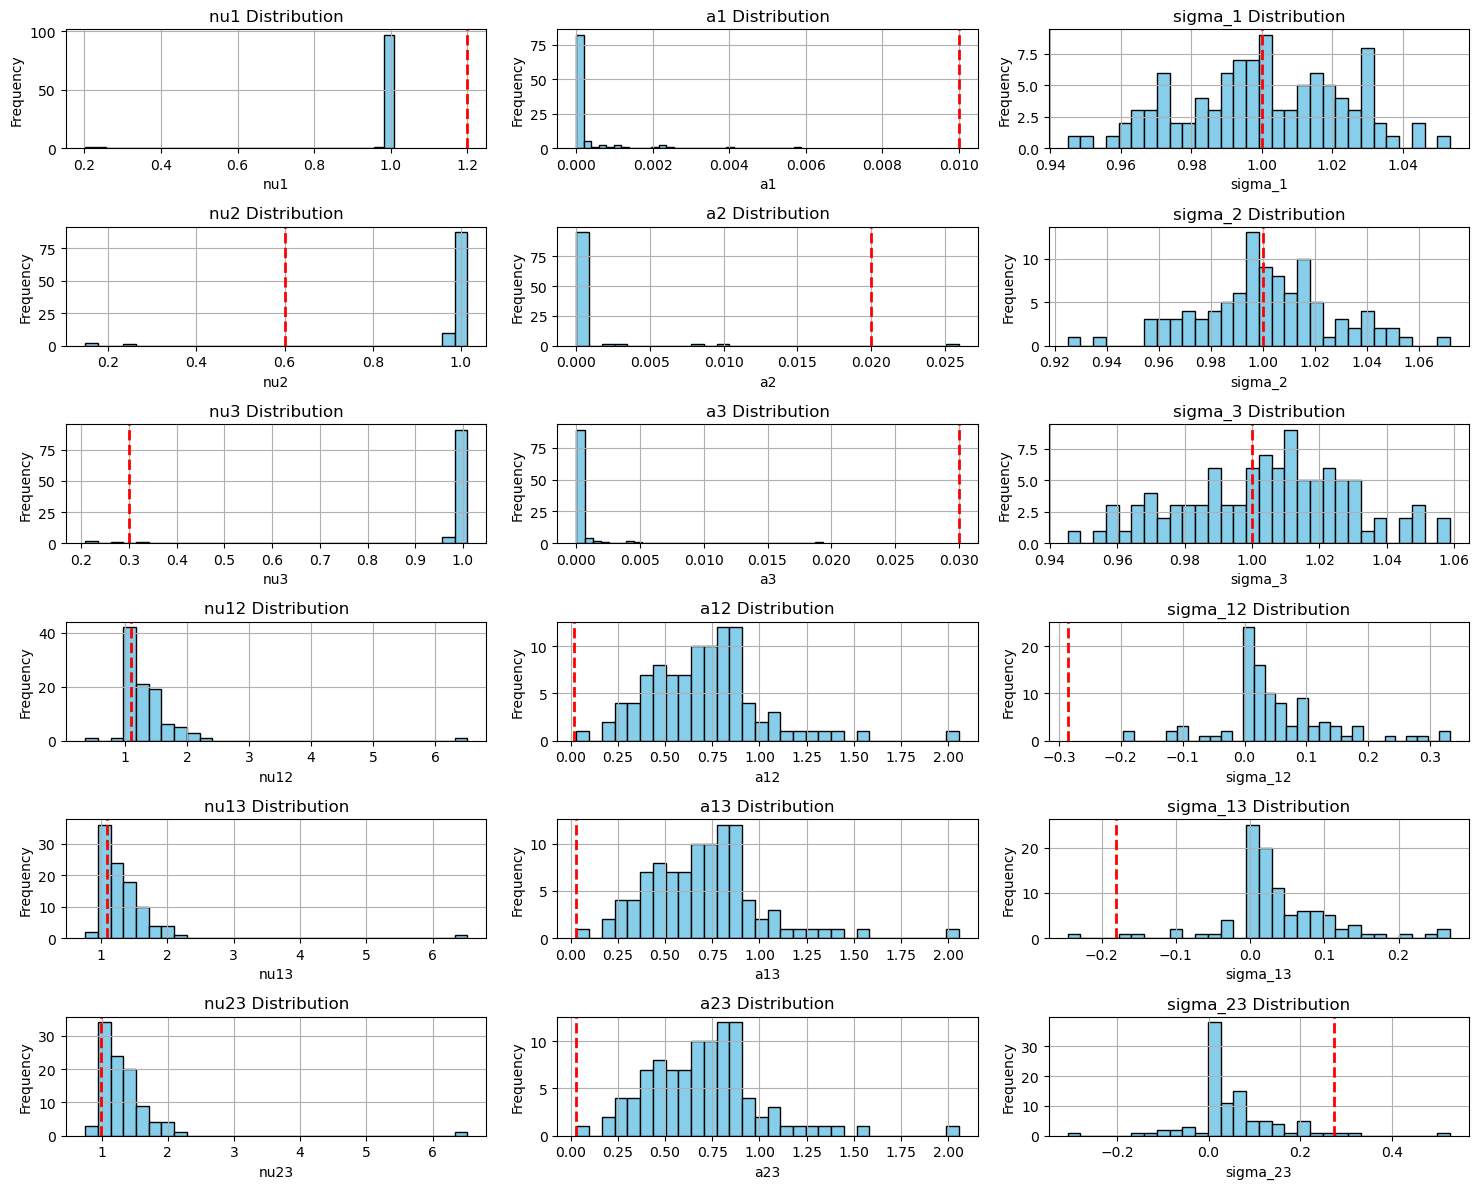

,nu1,a1,sigma_1,nu2,a2,sigma_2,nu3,a3,sigma_3,nu12,a12,sigma_12,nu13,a13,sigma_13,nu23,a23,sigma_23
0,1.004891,9.568588e-05,0.968216,1.001073,1.192093e-07,0.978213,0.983052,1.192093e-07,1.049218,1.131427,0.870961,0.101993,1.122416,0.870961,0.007887,1.120507,0.870961,0.006444
1,0.999938,1.192093e-07,0.983708,1.005272,5.187964e-04,0.958741,1.006999,9.227799e-05,0.956439,1.074071,0.701117,0.014609,1.074934,0.701117,0.019093,1.077601,0.701117,0.084042
2,0.997118,1.192093e-07,0.993169,1.003625,1.192093e-07,0.968780,0.998223,1.192093e-07,0.988799,1.013154,0.426215,0.014132,1.010453,0.426215,0.031179,1.013707,0.426215,0.005637
3,0.201479,5.878065e-03,0.996480,0.175132,2.594492e-02,0.993053,0.993569,1.192093e-07,1.008823,0.353662,0.216166,0.000572,0.762881,0.215386,0.000973,0.749708,0.216126,0.013654
4,0.997238,6.230072e-04,0.995870,0.992080,1.192093e-07,1.010452,0.982011,1.192093e-07,1.024771,1.153394,0.385255,0.176739,1.148359,0.385255,0.050727,1.145780,0.385255,0.040963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.992187,1.192093e-07,1.014297,0.991705,1.192093e-07,1.015378,0.994827,1.192093e-07,1.002655,1.023421,0.799314,0.015996,1.024981,0.799314,0.032409,1.024740,0.799314,0.014465
96,1.003698,1.192093e-07,0.965032,0.991890,4.681834e-04,1.016540,0.982578,1.340092e-03,1.032959,1.105462,0.659054,0.039981,1.100806,0.659054,0.022564,1.094902,0.659054,0.169551
97,0.983044,4.678496e-04,1.029809,0.991172,1.192093e-07,1.017112,0.992326,1.192093e-07,0.990810,1.004862,0.485335,0.003186,1.005439,0.485335,0.001655,1.009503,0.485335,0.002481
98,0.994623,1.192093e-07,1.003307,0.993868,1.192093e-07,1.005441,0.998135,1.192093e-07,0.989688,1.470654,0.457364,0.009763,1.472788,0.457364,0.005788,1.472410,0.457364,0.013709


In [9]:
# Plotting histograms with vertical lines for true values
plt.figure(figsize=(15, 12))
for i, col in enumerate(columns):
    plt.subplot(6, 3, i + 1)
    plt.hist(df_estimates[col], bins=30, color='skyblue', edgecolor='black')
    plt.axvline(x=true_values[col], color='red', linestyle='--', linewidth=2)
    plt.title(f'{col} Distribution')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

df_estimates

In [10]:
# Debugging code

# X, y_data, y_data_first, y_data_second, y_data_third, data = simulate_trivariate_data(data_size = 500)
# result_first = optimise_marginal(y_data_first)
# result_second = optimise_marginal(y_data_second)
# result_third = optimise_marginal(y_data_third)
# nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
# nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x
# nu3_estimated, a3_estimated, sigma_3_estimated = result_third.x

# X, y_data, y_data_first, y_data_second, y_data_third, data = simulate_trivariate_data(data_size=25)

# # estimate the first 9 parameters marginally
# result_first = optimise_marginal(y_data_first)
# result_second = optimise_marginal(y_data_second)
# result_third = optimise_marginal(y_data_third)
# nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
# nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x
# nu3_estimated, a3_estimated, sigma_3_estimated = result_third.x
# estimated_params = [nu1_estimated, a1_estimated, sigma_1_estimated, nu2_estimated, a2_estimated, sigma_2_estimated, nu3_estimated, a3_estimated, sigma_3_estimated]